# Binary Adders, CMOS Gates, and Gray Code

How a computer adds, from the transistor up: Boolean gates → half adder → full adder →
ripple-carry adder → carry-lookahead (the fast one) → Gray code. Every result is checked against
plain integer arithmetic, and the gate equations are proven with SymPy Boolean algebra.

| layer | object | this notebook |
|---|---|---|
| transistors | CMOS NAND/NOR | §1 |
| 1-bit | half / full adder | §2 |
| N-bit | ripple-carry (a loop) | §3 |
| fast | carry-lookahead | §4 |
| encoding | Gray code | §5 |
| code | Java reference adder | §6 |

Engine: the repo's `digital_logic.py`.

In [1]:
import sys, pathlib, itertools
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from dgs import digital_logic as dl

print("digital_logic loaded")

digital_logic loaded


## §1 CMOS gates: NAND and NOR are the cheap primitives

Static CMOS builds every gate from complementary pull-up (PMOS) / pull-down (NMOS) networks. **NAND**
and **NOR** cost only 4 transistors and are each *universal* (any logic function is reachable from
NAND alone) — which is why synthesis tools map designs onto them. AND/OR cost more (a NAND/NOR plus an
inverter), and XOR is the expensive one (~12T), which matters because the adder's sum is an XOR.

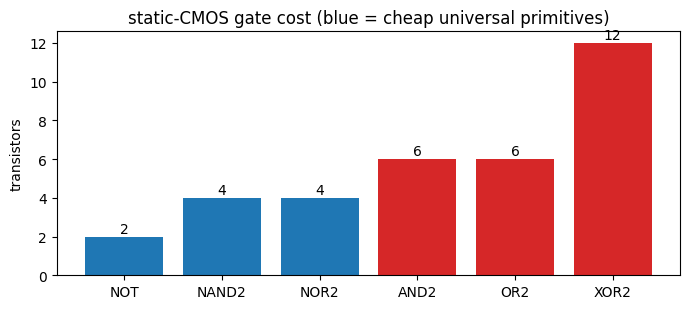

XOR (the adder's sum gate) is ~3x a NAND -> XOR-heavy logic is area-expensive.


In [2]:
gates = ["NOT", "NAND2", "NOR2", "AND2", "OR2", "XOR2"]
costs = [dl.cmos_cost(g) for g in gates]
plt.figure(figsize=(7, 3.2))
bars = plt.bar(gates, costs, color=["C0" if g in ("NAND2","NOR2","NOT") else "C3" for g in gates])
plt.ylabel("transistors"); plt.title("static-CMOS gate cost (blue = cheap universal primitives)")
for b, c in zip(bars, costs):
    plt.text(b.get_x()+b.get_width()/2, c+0.2, str(c), ha="center")
plt.tight_layout(); plt.show()
print("XOR (the adder's sum gate) is ~3x a NAND -> XOR-heavy logic is area-expensive.")

## §2 Half adder and full adder

A **half adder** adds two bits: $\text{sum}=a\oplus b$, $\text{carry}=a\wedge b$. A **full adder**
also takes a carry-in; chaining two half adders gives $\text{sum}=a\oplus b\oplus c_{in}$ and
$c_{out}=\text{majority}(a,b,c_{in})$. SymPy confirms the Boolean forms, and the truth table matches
$a+b+c_{in}$ exactly.

In [3]:
s_expr, c_expr = dl.adder_boolean()
from IPython.display import display, Math
display(Math(r"\text{sum} = " + sp.latex(s_expr)))
display(Math(r"c_{out} = " + sp.latex(c_expr) + r"\quad(\text{majority of } a,b,c_{in})"))

print("\nfull-adder truth table:")
print("  a b cin | sum cout | a+b+cin")
for a, b, cin in itertools.product((0, 1), repeat=3):
    s, c = dl.full_adder(a, b, cin)
    print(f"  {a} {b}  {cin}  |  {s}   {c}   |   {a+b+cin}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>


full-adder truth table:
  a b cin | sum cout | a+b+cin
  0 0  0  |  0   0   |   0
  0 0  1  |  1   0   |   1
  0 1  0  |  1   0   |   1
  0 1  1  |  0   1   |   2
  1 0  0  |  1   0   |   1
  1 0  1  |  0   1   |   2
  1 1  0  |  0   1   |   2
  1 1  1  |  1   1   |   3


## §3 The ripple-carry adder — a loop of full adders

Wire $N$ full adders in a chain, each feeding its carry to the next. The carry *ripples* from LSB to
MSB — simple, but the worst-case delay grows linearly with $N$ (the carry must propagate through
every stage). Verified against integer addition for all 4-bit operand pairs.

In [4]:
n = 4
x, y = 11, 7
sbits, cout = dl.ripple_carry_add(dl.int_to_bits(x, n), dl.int_to_bits(y, n))
print(f"{x} + {y}:  sum bits (LSB first) = {sbits}, carry-out = {cout}")
print(f"  = {dl.bits_to_int(sbits) + (cout << n)}  (check: {x + y})")

# exhaustive check
allok = all(
    dl.bits_to_int(dl.ripple_carry_add(dl.int_to_bits(a, n), dl.int_to_bits(b, n))[0])
    + (dl.ripple_carry_add(dl.int_to_bits(a, n), dl.int_to_bits(b, n))[1] << n) == a + b
    for a in range(2**n) for b in range(2**n))
print(f"ripple-carry == integer add for all {2**n}x{2**n} 4-bit pairs:", allok)

11 + 7:  sum bits (LSB first) = [0, 1, 0, 0], carry-out = 1
  = 18  (check: 18)
ripple-carry == integer add for all 16x16 4-bit pairs: True


## §4 Carry-lookahead — the fast adder ("new technology")

The ripple's linear delay is the bottleneck. **Carry-lookahead** computes every carry *in parallel*
from generate $g_i=a_i\wedge b_i$ and propagate $p_i=a_i\oplus b_i$ signals:

$$c_{i+1}=g_i\;\vee\;(p_i\wedge c_i).$$

Unrolling this recurrence lets all carries be formed in $O(\log N)$ gate depth instead of $O(N)$ —
the same answer, far less latency. It matches ripple-carry bit-for-bit.

carry-lookahead identical to ripple-carry on all 4-bit pairs: True

13 + 11:  a=[1, 1, 0, 1] b=[1, 0, 1, 1] (MSB-first)
  generate g = [1, 0, 0, 1]   propagate p = [0, 1, 1, 0]
  carries fan out in parallel from these, no waiting for the ripple.


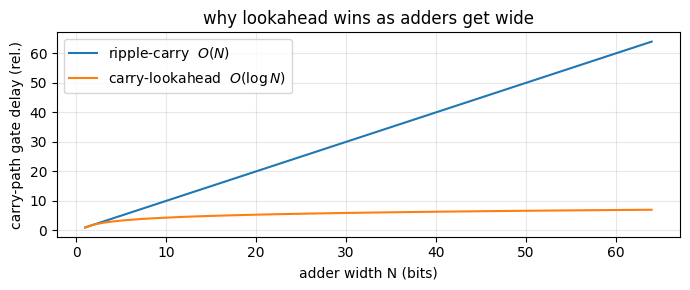

In [5]:
same = all(
    dl.carry_lookahead(dl.int_to_bits(a, n), dl.int_to_bits(b, n))
    == dl.ripple_carry_add(dl.int_to_bits(a, n), dl.int_to_bits(b, n))
    for a in range(2**n) for b in range(2**n))
print("carry-lookahead identical to ripple-carry on all 4-bit pairs:", same)

# illustrate generate/propagate for one example
a_bits, b_bits = dl.int_to_bits(13, n), dl.int_to_bits(11, n)
g = [a_bits[i] & b_bits[i] for i in range(n)]
p = [a_bits[i] ^ b_bits[i] for i in range(n)]
print(f"\n13 + 11:  a={a_bits[::-1]} b={b_bits[::-1]} (MSB-first)")
print(f"  generate g = {g[::-1]}   propagate p = {p[::-1]}")
print("  carries fan out in parallel from these, no waiting for the ripple.")

# delay scaling cartoon
N = np.arange(1, 65)
plt.figure(figsize=(7, 3))
plt.plot(N, N, label="ripple-carry  $O(N)$")
plt.plot(N, np.log2(N) + 1, label="carry-lookahead  $O(\\log N)$")
plt.xlabel("adder width N (bits)"); plt.ylabel("carry-path gate delay (rel.)")
plt.legend(); plt.title("why lookahead wins as adders get wide"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §5 Gray code — one bit changes at a time

Reflected **Gray code** orders the integers so that successive values differ in exactly **one** bit
($g = n\oplus(n\!\gg\!1)$). That single-bit property eliminates the transient glitches that plague
ordinary binary counters (where e.g. $0111\to1000$ flips four bits at once), which is why rotary
encoders, ADCs, and state machines use it.

i  binary  Gray   bits changed
 0  0000   0000   -
 1  0001   0001   1
 2  0010   0011   1
 3  0011   0010   1
 4  0100   0110   1
 5  0101   0111   1
 6  0110   0101   1
 7  0111   0100   1
 8  1000   1100   1
 9  1001   1101   1
10  1010   1111   1
11  1011   1110   1
12  1100   1010   1
13  1101   1011   1
14  1110   1001   1
15  1111   1000   1

round-trip from_gray(to_gray(i))==i for 0..255: True


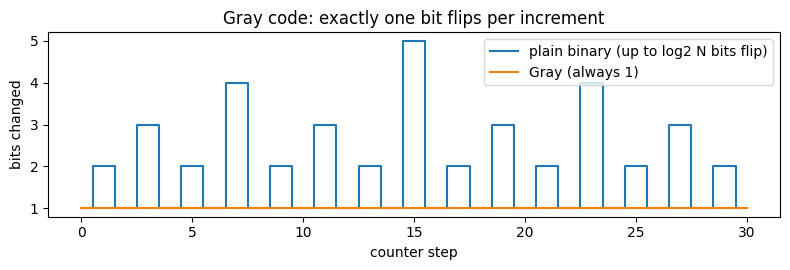

In [6]:
codes = [dl.to_gray(i) for i in range(16)]
print("i  binary  Gray   bits changed")
prev = None
for i in range(16):
    g = dl.to_gray(i)
    changed = "-" if prev is None else bin(g ^ prev).count("1")
    print(f"{i:2}  {i:04b}   {g:04b}   {changed}")
    prev = g

# round-trip + single-bit guarantee
print("\nround-trip from_gray(to_gray(i))==i for 0..255:",
      all(dl.from_gray(dl.to_gray(i)) == i for i in range(256)))

# visualize: Hamming distance between consecutive codes, binary vs Gray
N = 32
bin_hd = [bin(i ^ (i+1)).count("1") for i in range(N-1)]
gray_hd = [bin(dl.to_gray(i) ^ dl.to_gray(i+1)).count("1") for i in range(N-1)]
plt.figure(figsize=(8, 2.8))
plt.step(range(N-1), bin_hd, where="mid", label="plain binary (up to log2 N bits flip)")
plt.step(range(N-1), gray_hd, where="mid", label="Gray (always 1)")
plt.xlabel("counter step"); plt.ylabel("bits changed"); plt.legend()
plt.title("Gray code: exactly one bit flips per increment"); plt.tight_layout(); plt.show()

## §6 Decoder, priority encoder, multiplexer — routing and selecting

Arithmetic is only half of logic; the other half is **steering bits**. A
**decoder** turns an $n$-bit address into one asserted line out of $2^n$ (the
inverse, a **priority encoder**, collapses one-hot back to a binary index). A
**multiplexer** picks one of $2^n$ data words by its select bits. These are the
glue that wires a datapath — and the decoder is exactly what turns an *opcode*
into the single control line that fires one operation.

In [7]:
print("3-to-8 decoder (address -> one-hot line):")
for i in range(8):
    print(f"  addr {i:03b} -> {dl.decoder(dl.int_to_bits(i, 3))}")

oh = dl.decoder(dl.int_to_bits(5, 3))
idx, valid = dl.priority_encoder(oh)
print(f"\npriority encoder: one-hot {oh} -> index {dl.bits_to_int(idx)} (valid={valid})")

data = [0b1010, 0b0101, 0b1111, 0b0000]
print("\n4:1 mux (select one data word):")
for s in range(4):
    print(f"  sel {s:02b} -> {dl.mux(data, dl.int_to_bits(s, 2)):04b}")

3-to-8 decoder (address -> one-hot line):
  addr 000 -> [1, 0, 0, 0, 0, 0, 0, 0]
  addr 001 -> [0, 1, 0, 0, 0, 0, 0, 0]
  addr 010 -> [0, 0, 1, 0, 0, 0, 0, 0]
  addr 011 -> [0, 0, 0, 1, 0, 0, 0, 0]
  addr 100 -> [0, 0, 0, 0, 1, 0, 0, 0]
  addr 101 -> [0, 0, 0, 0, 0, 1, 0, 0]
  addr 110 -> [0, 0, 0, 0, 0, 0, 1, 0]
  addr 111 -> [0, 0, 0, 0, 0, 0, 0, 1]

priority encoder: one-hot [0, 0, 0, 0, 0, 1, 0, 0] -> index 5 (valid=1)

4:1 mux (select one data word):
  sel 00 -> 1010
  sel 01 -> 0101
  sel 10 -> 1111
  sel 11 -> 0000


## §7 An ALU and a tiny instruction set — the 0/1 mental model of a CPU

Stack it all up: the basic **gates** build the **adder** (§2–3); the adder plus
the bitwise gates build an **ALU**; and an **opcode** selects which ALU operation
runs. That opcode is just an address — a **decoder** (§6) turns it into the one
control line that gates the datapath. That is the whole "how does a computer
execute an instruction" picture in one page:

$$\text{gates}\;\to\;\text{adder}\;\to\;\text{ALU}\;\to\;\text{instruction set}.$$

`SUB` is two's-complement add ($a+\lnot b+1$); the **flags** (zero, carry,
negative) are what `if`/branch instructions test.

In [8]:
a, b = 13, 6
ab, bb = dl.int_to_bits(a, 4), dl.int_to_bits(b, 4)
print(f"a = {a} ({a:04b}),  b = {b} ({b:04b})\n")
print("opcode  op    result      flags")
for op, name in dl.ALU_OPS.items():
    res, fl = dl.alu(name, ab, bb)
    print(f"  {op:03b}   {name:4}  {dl.bits_to_int(res):>2} ({dl.bits_to_int(res):04b})  {fl}")

print("\nthe decoder IS the instruction decoder (opcode -> one control line):")
for op, name in dl.ALU_OPS.items():
    print(f"  {op:03b} {name:4} -> {dl.decoder(dl.int_to_bits(op, 3))}")

a = 13 (1101),  b = 6 (0110)

opcode  op    result      flags
  000   ADD    3 (0011)  {'zero': 0, 'carry': 1, 'negative': 0}
  001   SUB    7 (0111)  {'zero': 0, 'carry': 1, 'negative': 0}
  010   AND    4 (0100)  {'zero': 0, 'carry': 0, 'negative': 0}
  011   OR    15 (1111)  {'zero': 0, 'carry': 0, 'negative': 1}
  100   XOR   11 (1011)  {'zero': 0, 'carry': 0, 'negative': 1}
  101   NOT    2 (0010)  {'zero': 0, 'carry': 0, 'negative': 0}
  110   PASS  13 (1101)  {'zero': 0, 'carry': 0, 'negative': 1}

the decoder IS the instruction decoder (opcode -> one control line):
  000 ADD  -> [1, 0, 0, 0, 0, 0, 0, 0]
  001 SUB  -> [0, 1, 0, 0, 0, 0, 0, 0]
  010 AND  -> [0, 0, 1, 0, 0, 0, 0, 0]
  011 OR   -> [0, 0, 0, 1, 0, 0, 0, 0]
  100 XOR  -> [0, 0, 0, 0, 1, 0, 0, 0]
  101 NOT  -> [0, 0, 0, 0, 0, 1, 0, 0]
  110 PASS -> [0, 0, 0, 0, 0, 0, 1, 0]


## §8 "Adder in Java" — the reference implementation

The same ripple-carry adder in Java (gate logic with `^`, `&`, `|` on bits). The Python above is the
*executable* version here; this is the Java you'd hand in for a digital-design / Java course.

```java
public class RippleCarryAdder {
    // one full adder: returns {sum, carryOut}
    static int[] fullAdder(int a, int b, int cin) {
        int s1 = a ^ b;
        int c1 = a & b;
        int sum = s1 ^ cin;
        int cout = c1 | (s1 & cin);   // majority(a,b,cin)
        return new int[]{sum, cout};
    }

    // N-bit ripple-carry add of LSB-first bit arrays
    static int[] add(int[] a, int[] b) {
        int n = Math.max(a.length, b.length);
        int[] sum = new int[n + 1];   // last slot = final carry
        int carry = 0;
        for (int i = 0; i < n; i++) {
            int ai = i < a.length ? a[i] : 0;
            int bi = i < b.length ? b[i] : 0;
            int[] fa = fullAdder(ai, bi, carry);
            sum[i] = fa[0];
            carry  = fa[1];
        }
        sum[n] = carry;
        return sum;
    }

    static int toGray(int x) { return x ^ (x >> 1); }

    public static void main(String[] args) {
        int[] a = {1, 1, 0, 1};       // 11 (LSB first)
        int[] b = {1, 1, 1, 0};       // 7
        int[] s = add(a, b);
        int val = 0;
        for (int i = 0; i < s.length; i++) val |= s[i] << i;
        System.out.println("11 + 7 = " + val);          // 18
        System.out.println("Gray(7) = " + Integer.toBinaryString(toGray(7)));  // 100
    }
}
```

(No JDK is wired into this repo, so the cell above is reference text; the Python in §3 is the run-and-
verified twin — same `fullAdder`, same loop.)

## §9 Connections

- **Boolean algebra → CMOS → arithmetic** is one unbroken stack: §2's $a\oplus b\oplus c_{in}$ is
  literally the XOR gates of §1 wired by §3's loop. SymPy proving the gate equations is the same
  symbolic-verification discipline as the `griffiths` physics package.
- **Ripple vs lookahead** is a latency/area trade — the digital cousin of the speed/smoothness and
  damping trade-offs elsewhere in this repo (jerk profiles, RLC). "New technology" in adders is
  almost always a cleverer carry network (Kogge-Stone, Brent-Kung) on the same generate/propagate idea.
- **Gray code** is the discrete face of "change one thing at a time" — glitch-free transitions, the
  reason ADC/encoder front ends (including the timing logic feeding this repo's GS pipeline) use it.
- **Gates → adder → ALU → instruction set** (§7) is the bottom-up computer-engineering ladder. It is
  not abstract here: the repo's Verilog FFT core (`hardware/fft8.v`) is built from exactly these
  butterflies — complex add/subtract on fixed-point words, i.e. the ALU's `ADD`/`SUB` wired in the
  radix-2 pattern. The decoder that turns an opcode into a control line is the same decoder that would
  sequence that core.

Module: `digital_logic.py` — adders, carry-lookahead, Gray code, CMOS cost, SymPy Boolean, the **7
basic gates** (NAND/NOR universal), decoder/priority-encoder/mux, and an **ALU + instruction set**;
all checked in `scripts/smoke_digital.py`.